In [1]:
import sys
import os
if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))

from matplotlib import pyplot as plt
import conquer3d as c3d
import open3d as o3d
from conquer3d.ops.delaunay_triangulation import tetrahedralize, get_edges
from conquer3d.ops.marching_tetrahedra import marching_tetrahedra


import torch
import tqdm
import numpy as np
import kaolin as kal
import render
import open3d as o3d
import util
import nvdiffrast.torch as dr


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
iter = 1000
batch = 8
train_res = [2048, 2048]
learning_rate = 0.01
device = 'cuda'

glctx = dr.RasterizeCudaContext(device=device)

In [3]:
mesh = o3d.io.read_triangle_mesh(o3d.data.BunnyMesh().path)

print("# vertices:", len(mesh.vertices))
print("# triangles:", len(mesh.triangles))

print(type(mesh))

# vertices: 35947
# triangles: 69451
<class 'open3d.cuda.pybind.geometry.TriangleMesh'>


In [4]:
# Make front face towards +Z
R = mesh.get_rotation_matrix_from_xyz((0, np.pi, 0))
mesh.rotate(R, center=(0, 0, 0))

TriangleMesh with 35947 points and 69451 triangles.

In [5]:
vertices = np.asarray(mesh.vertices).astype(np.float32)
triangles = np.asarray(mesh.triangles).astype(np.int64)

print(f"vertices: {vertices.shape}, triangles: {triangles.shape}")
print(f"vertices: {vertices.dtype}, triangles: {triangles.dtype}")
print(f"vertices min: {vertices.min()},\nvertices max: {vertices.max()}")

vertices: (35947, 3), triangles: (69451, 3)
vertices: float32, triangles: int64
vertices min: -0.06100910156965256,
vertices max: 0.1873210072517395


In [6]:
vertices = torch.from_numpy(vertices).float()
triangles = torch.from_numpy(triangles).long()

vmin, vmax = vertices.min(dim=0)[0], vertices.max(dim=0)[0]
scale = 1.8 / torch.max(vmax - vmin).item()

vertices = vertices - (vmax + vmin) / 2
vertices = vertices * scale

print(f"vertices min: {vertices.min()}, \nvertices max: {vertices.max()}")
print(f"vertices: {vertices.shape}, triangles: {triangles.shape}")

vertices min: -0.9000000357627869, 
vertices max: 0.9000000357627869
vertices: torch.Size([35947, 3]), triangles: torch.Size([69451, 3])


In [7]:
vertices = vertices.to(device)
triangles = triangles.to(device)

gt_mesh = kal.rep.SurfaceMesh(vertices=vertices, faces=triangles)

In [8]:
num_sampling_points = 100000

pc, _ = kal.ops.mesh.sample_points(gt_mesh.vertices.unsqueeze(0), gt_mesh.faces, num_sampling_points)
pc = pc.squeeze(0)

print(f"pc: {pc.shape}, {pc.dtype}")

pc: torch.Size([100000, 3]), torch.float32


In [9]:
def create_random_points_ball(n_points, radius=1.0):
    points = torch.randn(n_points, 3, device=device)
    radii = torch.rand(n_points, 1, device=device) ** (1/3) * radius
    points = (points / points.norm(dim=-1, keepdim=True)) * radii
    return points

grid_vertices = create_random_points_ball(100000, 1.2)
tetras = tetrahedralize(grid_vertices)

print(f"grid_vertices: {grid_vertices.shape}, tetras: {tetras.shape}")
print(f"grid_vertices: {grid_vertices.dtype}, tetras: {tetras.dtype}")
print(f"grid_vertices min: {grid_vertices.min()}, grid_vertices max: {grid_vertices.max()}")

grid_vertices: torch.Size([100000, 3]), tetras: torch.Size([669117, 4])
grid_vertices: torch.float32, tetras: torch.int64
grid_vertices min: -1.1974760293960571, grid_vertices max: 1.1971205472946167


In [10]:
sdf = torch.rand_like(grid_vertices[:,0]) - 0.1
sdf = torch.nn.Parameter(sdf.clone().detach(), requires_grad=True)
grid_vertices = torch.nn.Parameter(grid_vertices.clone().detach(), requires_grad=True)

print(f"sdf: {sdf.shape}, {sdf.dtype}")
print(f"sdf min: {sdf.min()}, sdf max: {sdf.max()}")
print(f"sdf requires_grad: {sdf.requires_grad}")

sdf: torch.Size([100000]), torch.float32
sdf min: -0.09997773170471191, sdf max: 0.8999767899513245
sdf requires_grad: True


vertices: torch.Size([139152, 3]), faces: torch.Size([263098, 3])


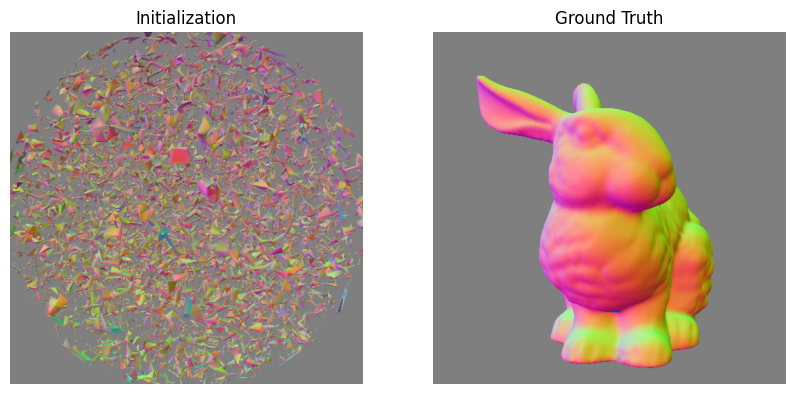

In [11]:
with torch.no_grad():
    mc_vertices, mc_faces = marching_tetrahedra(grid_vertices, tetras, sdf)

print(f"vertices: {mc_vertices.shape}, faces: {mc_faces.shape}")
if mc_vertices.shape[0] > 0:
    init_mesh = kal.rep.SurfaceMesh(vertices=mc_vertices, faces=mc_faces)
    
    camera = render.get_rotate_camera(5)
    f, ax = plt.subplots(1, 2, figsize=(10, 5))
    output = render.render_mesh(glctx, init_mesh, camera, [512, 512], return_types=['normals'])
    ax[0].imshow(((output['normals'][0] + 1) / 2.).cpu().detach().numpy())
    ax[0].set_title("Initialization")
    ax[0].axis('off')
    
    output = render.render_mesh(glctx, gt_mesh, camera, [512, 512], return_types=['normals'])
    ax[1].imshow(((output['normals'][0] + 1) / 2.).cpu().detach().numpy())
    ax[1].set_title("Ground Truth")
    ax[1].axis('off')
    plt.show()


In [12]:
def lr_schedule(iter):
    return max(0.0, 10 ** (-(iter) * 0.0002)) # Exponential falloff from [1.0, 0.1] over 5k epochs.    
optimizer = torch.optim.Adam([{'params': sdf}, {'params': grid_vertices, 'lr': learning_rate}], lr=learning_rate)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda x: lr_schedule(x))

In [13]:
def sdf_reg_loss(sdf, all_edges):
    sdf_f1x6x2 = sdf[all_edges.reshape(-1)].reshape(-1,2)
    mask = torch.sign(sdf_f1x6x2[...,0]) != torch.sign(sdf_f1x6x2[...,1])
    sdf_f1x6x2 = sdf_f1x6x2[mask]
    sdf_diff = torch.nn.functional.binary_cross_entropy_with_logits(sdf_f1x6x2[...,0], (sdf_f1x6x2[...,1] > 0).float()) + \
            torch.nn.functional.binary_cross_entropy_with_logits(sdf_f1x6x2[...,1], (sdf_f1x6x2[...,0] > 0).float())
    return sdf_diff

In [14]:
for it in tqdm.tqdm(range(iter)): 
    optimizer.zero_grad()
    if it % 10 == 0:
        tetras = tetrahedralize(grid_vertices)

    # sample random camera poses
    cameras = render.get_random_camera_batch(batch, iter_res=train_res, device=device)
    
    # render gt mesh at sampled views
    target = render.render_mesh(glctx, gt_mesh, cameras, train_res, return_types = ["mask", "depth", "normals"])

    # mesh extraction
    mc_vertices, mc_faces = marching_tetrahedra(grid_vertices, tetras, sdf)
    
    if mc_vertices.shape[0] == 0:
        continue
    
    extracted_mesh = kal.rep.SurfaceMesh(vertices=mc_vertices, faces=mc_faces.int())
    buffers = render.render_mesh(glctx, extracted_mesh, cameras, train_res, return_types = ["mask", "depth", "normals"])

    # reconstruction loss
    mask_loss = (buffers['mask'] - target['mask']).abs().mean() # mask loss
    depth_loss = (((((buffers['depth'] - (target['depth'])) * target['mask'])**2).sum(-1)+1e-8)).sqrt().mean() * 10 # depth loss

    normal_loss = (((((buffers['normals'] - target['normals']) * target['mask'])**2).sum(-1)+1e-8)).sqrt().mean() * 1.0
    edges = get_edges(tetras)
    reg_sdf_loss = sdf_reg_loss(sdf, edges.reshape(-1, 2)).mean() * 0.1
    total_loss = mask_loss + depth_loss + normal_loss + reg_sdf_loss
    total_loss.backward()
    optimizer.step()
    scheduler.step()
    
    if (it + 1) % 100 == 0: # save intermediate results every 100 iters
        tqdm.tqdm.write(f"Iter {it+1}/{iter}, Mask Loss: {mask_loss.item():.4f}, Depth Loss: {depth_loss.item():.4f}, Normal Loss: {normal_loss.item():.4f}, Reg SDF Loss: {reg_sdf_loss.item():.4f}, Total Loss: {total_loss.item():.4f}")


 10%|█         | 100/1000 [00:19<01:46,  8.42it/s]

Iter 100/1000, Mask Loss: 0.0059, Depth Loss: 0.0998, Normal Loss: 0.1264, Reg SDF Loss: 0.1555, Total Loss: 0.3877


 20%|██        | 200/1000 [00:39<01:34,  8.44it/s]

Iter 200/1000, Mask Loss: 0.0046, Depth Loss: 0.0853, Normal Loss: 0.1128, Reg SDF Loss: 0.1546, Total Loss: 0.3574


 30%|███       | 300/1000 [00:58<01:22,  8.44it/s]

...

Iter 800/1000, Mask Loss: 0.0036, Depth Loss: 0.0661, Normal Loss: 0.0943, Reg SDF Loss: 0.1532, Total Loss: 0.3172


 90%|█████████ | 900/1000 [02:54<00:11,  8.40it/s]

Iter 900/1000, Mask Loss: 0.0037, Depth Loss: 0.0545, Normal Loss: 0.0857, Reg SDF Loss: 0.1532, Total Loss: 0.2972


100%|██████████| 1000/1000 [03:13<00:00,  5.16it/s]

Iter 1000/1000, Mask Loss: 0.0035, Depth Loss: 0.0677, Normal Loss: 0.0851, Reg SDF Loss: 0.1529, Total Loss: 0.3092


In [15]:
with torch.no_grad():
    mc_vertices, mc_faces = marching_tetrahedra(grid_vertices, tetras, sdf)
    
final_mesh = kal.rep.SurfaceMesh(vertices=mc_vertices, faces=mc_faces)
print(f"Final vertices: {mc_vertices.shape}, Final faces: {mc_faces.shape}")


Final vertices: torch.Size([97127, 3]), Final faces: torch.Size([198574, 3])


In [16]:
# Evaluate using c3d chamfer distance
pc_prime, _ = kal.ops.mesh.sample_points(final_mesh.vertices.unsqueeze(0), final_mesh.faces, num_sampling_points)
pc_prime = pc_prime.squeeze(0)

chamfer_dist = c3d.ops.chamfer_distance(pc, pc_prime, squared=True)
print(f"Chamfer Distance: {chamfer_dist.item():.6f}")


Chamfer Distance: 0.004585


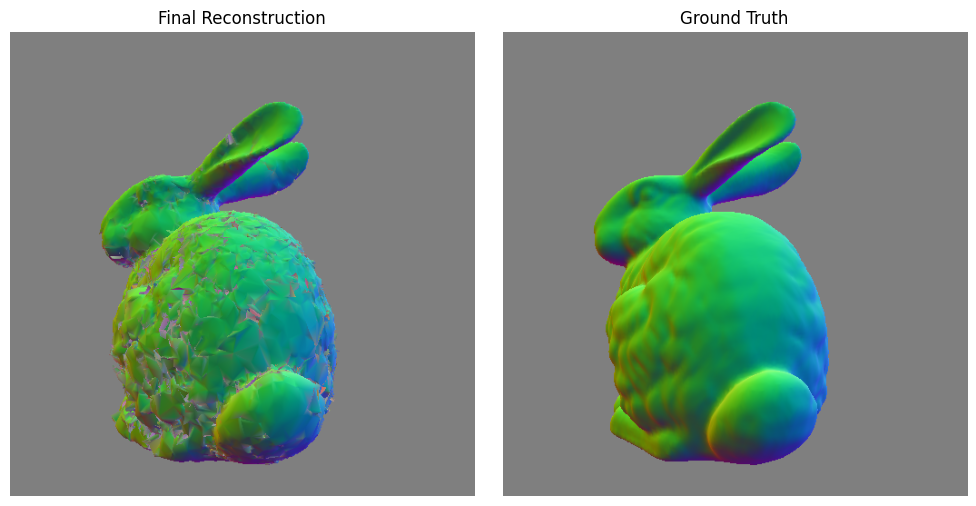

In [17]:
# Render the final oriented mesh using matplotlib (PNG) to keep notebook size minimal
camera = render.get_rotate_camera(0)
output_final = render.render_mesh(glctx, final_mesh, camera, [512, 512], return_types=['normals'])
img_final = ((output_final['normals'][0] + 1) / 2.).cpu().detach().numpy()

output_gt = render.render_mesh(glctx, gt_mesh, camera, [512, 512], return_types=['normals'])
img_gt = ((output_gt['normals'][0] + 1) / 2.).cpu().detach().numpy()

f, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_final)
ax[0].set_title("Final Reconstruction")
ax[0].axis('off')

ax[1].imshow(img_gt)
ax[1].set_title("Ground Truth")
ax[1].axis('off')

plt.tight_layout()
plt.show()

# Rotate final mesh around the X-axis by 90 degrees to make Z-upward axis
angle = torch.tensor(np.pi / 2, device=device)
R_x = torch.tensor([
    [1.0, 0.0, 0.0],
    [0.0, torch.cos(angle), -torch.sin(angle)],
    [0.0, torch.sin(angle), torch.cos(angle)]
], device=device)

final_mesh.vertices = torch.matmul(final_mesh.vertices, R_x.T)


In [18]:
# util.visualize_mesh(final_mesh, plot_wireframe=True)

In [19]:
from conquer3d.data_structure import TriangleMesh

# Evaluate topological properties using the C++ native TriangleMesh
c3d_mesh = TriangleMesh(
    final_mesh.vertices.detach(),
    final_mesh.faces.detach().to(torch.int32)
)

print("Is vertex manifold:", c3d_mesh.is_vertex_manifold())
print("Is edge manifold:", c3d_mesh.is_edge_manifold())
print("Has self intersection:", c3d_mesh.is_self_intersection())

Is vertex manifold: True
Is edge manifold: True
Has self intersection: True
